# Carregar blibliotecas e dataset


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import sweetviz as sv

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder
from sklearn.metrics import roc_auc_score, classification_report
from lightgbm import LGBMClassifier

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

In [2]:
df_origem = pd.read_csv("./dataset/consumer_shopping.csv")
df_origem.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Online
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [3]:
df_origem.info()

<class 'pandas.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_days          

In [4]:
df_origem.shopping_preference.value_counts(normalize=True)

shopping_preference
Store     0.868946
Online    0.131054
Name: proportion, dtype: float64

# Split

Antes de qualquer mudança, vamos separar os dados que serão usados na validação.<br>
Afinal, os dados de validação simulam dados em produção, eles não podem ser "vistos"!

In [40]:
TARGET = "shopping_preference"

df, df_validacao = train_test_split(
    df_origem, 
    test_size=0.2, 
    random_state=42,
    stratify=df_origem[TARGET]
)

# HOLDOUT FINAL: não tocar até o modelo estar completamente definido 
x_validacao = df_validacao.drop(columns=[TARGET])
y_validacao = df_validacao[TARGET]



# Tratamentos iniciais 

In [19]:
df["shopping_preference"] = df['shopping_preference'].map({
    'Online': 1,
    'Store': 0
})

# EDA 
- Entender a geração dos dados
- Localizar inconsistências
- Avaliar assimetrias
- Verificar outliers e missing

In [9]:
def feature_audit(X: pd.DataFrame) -> pd.DataFrame:
    n = len(X)

    audit = pd.DataFrame(index=X.columns)
    audit.index.name = "feature"

    audit["dtype"] = X.dtypes.astype(str)
    audit["missing_pct"] = X.isna().mean()
    audit["n_unique"] = X.nunique(dropna=False)
    audit["unique_pct"] = audit["n_unique"] / n

    audit["dominant_pct"] = X.apply(
        lambda s: s.value_counts(
            dropna=False,
            normalize=True
        ).iloc[0]
    )

    numeric = X.select_dtypes(include=np.number)

    audit["mean"] = numeric.mean()
    audit["std"] = numeric.std()
    audit["min"] = numeric.min()
    audit["p01"] = numeric.quantile(0.01)
    audit["median"] = numeric.median()
    audit["p99"] = numeric.quantile(0.99)
    audit["max"] = numeric.max()

    audit["constant"] = audit["n_unique"] <= 1
    audit["near_constant"] = audit["dominant_pct"] >= 0.995
    audit["mostly_missing"] = audit["missing_pct"] >= 0.95
    audit["id_like"] = audit["unique_pct"] >= 0.98

    return audit.sort_values(
        ["constant", "mostly_missing", "near_constant"],
        ascending=False
    )

In [10]:
feature_audit(df)

,dtype,missing_pct,n_unique,unique_pct,dominant_pct,mean,std,min,p01,median,p99,max,constant,near_constant,mostly_missing,id_like
feature,,,,,,,,,,,,,,,,
shopping_preference,float64,1.0,1,0.000106,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,True,False
age,int64,0.0,62,0.006574,0.019298,48.748595,17.889181,18.0,18.0,49.0,79.0,79.0,False,False,False,False
monthly_income,int64,0.0,9251,0.980914,0.000318,131518.005514,68190.389456,15005.0,17204.2,131360.0,247824.3,249989.0,False,False,False,True
daily_internet_hours,float64,0.0,111,0.011770,0.021843,6.005768,1.977116,1.0,1.5,6.0,10.6,12.0,False,False,False,False
smartphone_usage_years,int64,0.0,14,0.001484,0.078041,7.573640,4.011815,1.0,1.0,8.0,14.0,14.0,False,False,False,False
social_media_hours,float64,0.0,61,0.006468,0.033825,2.525331,1.265695,0.0,0.0,2.5,5.5,6.0,False,False,False,False
online_payment_trust_score,int64,0.0,10,0.001060,0.102640,5.488920,2.873298,1.0,1.0,5.0,10.0,10.0,False,False,False,False
tech_savvy_score,int64,0.0,10,0.001060,0.108684,5.539603,2.907717,1.0,1.0,6.0,10.0,10.0,False,False,False,False
monthly_online_orders,int64,0.0,50,0.005302,0.024282,24.723571,14.475336,0.0,0.0,25.0,49.0,49.0,False,False,False,False


In [11]:
df.describe()

feature,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,shopping_preference
count,9431.000000,9431.000000,9431.000000,9431.000000,9431.000000,9431.000000,9431.000000,9431.000000,9431.000000,9431.000000,...,9431.000000,9431.000000,9431.000000,9431.000000,9431.000000,9431.000000,9431.000000,9431.000000,9431.000000,0.0
mean,48.748595,131518.005514,6.005768,7.573640,2.525331,5.488920,5.539603,24.723571,9.475877,74929.972643,...,4.010285,5.472908,5.448097,5.529530,5.490404,5.486481,5.520517,5.443749,5.495069,NaN
std,17.889181,68190.389456,1.977116,4.011815,1.265695,2.873298,2.907717,14.475336,5.715584,43201.400647,...,1.995754,2.884758,2.881843,2.872983,2.880160,2.877676,2.840097,2.872473,2.885542,NaN
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,529.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
25%,33.000000,71994.000000,4.600000,4.000000,1.650000,3.000000,3.000000,12.000000,5.000000,37429.000000,...,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,NaN
50%,49.000000,131360.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,75231.000000,...,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000,NaN
75%,64.000000,190386.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112607.000000,...,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,NaN
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,NaN


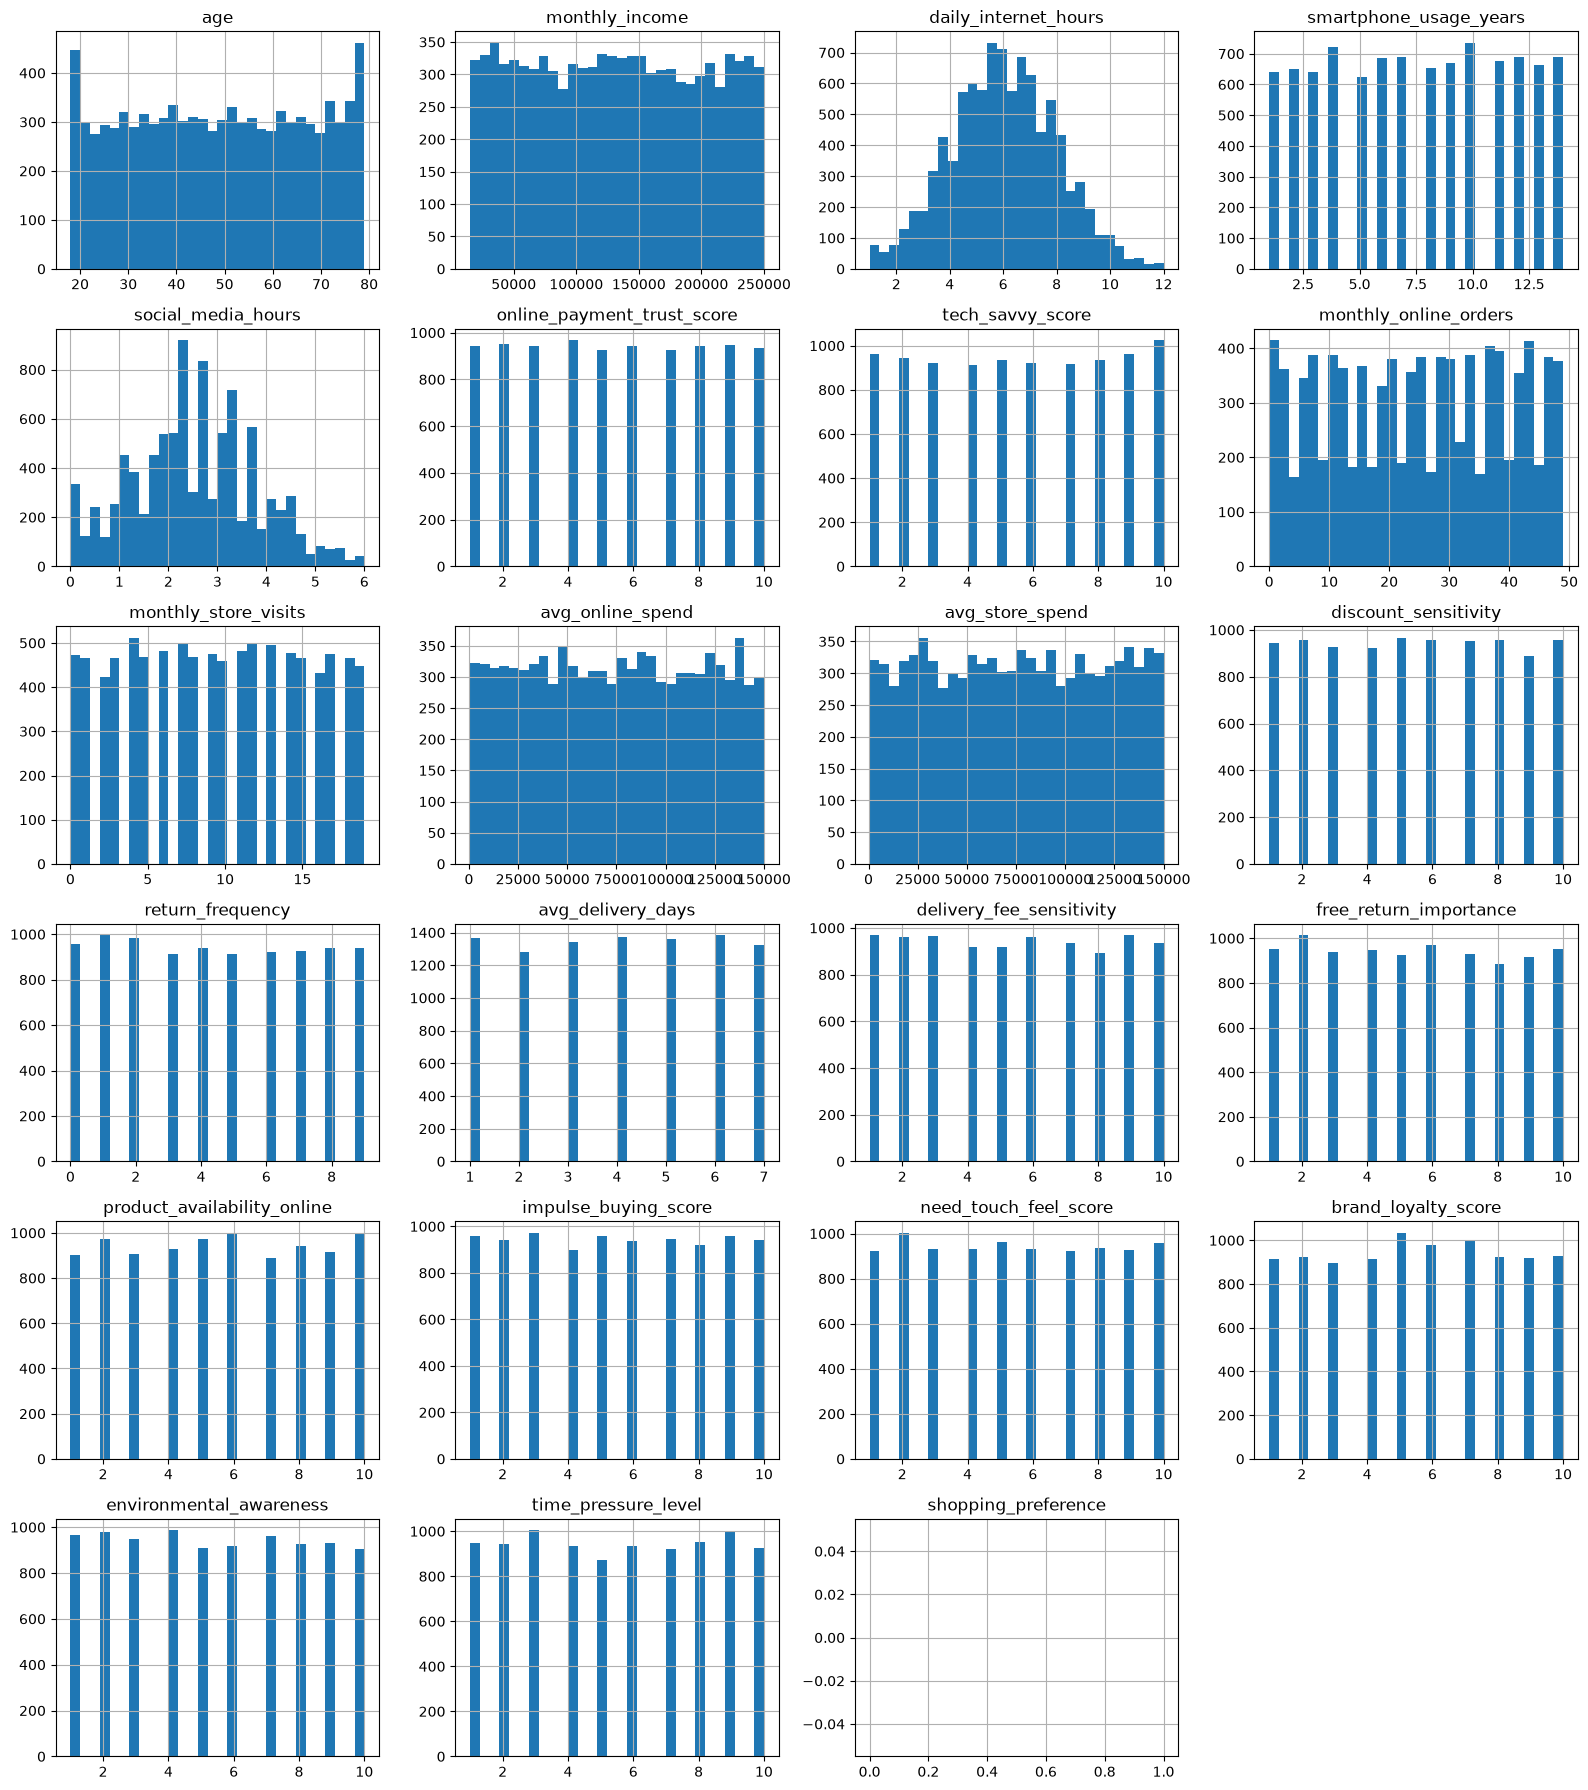

In [12]:
num_cols = df.select_dtypes(include="number").columns
df[num_cols].hist(
    bins=30,
    figsize=(16, 3 * ((len(num_cols) + 3) // 4)),
    layout=(-1, 4)
)
plt.tight_layout()

In [21]:
report = sv.analyze(
    [df, "data"],
    target_feat="shopping_preference"
)

Feature: shopping_preference (TARGET)        |▍         | [  4%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: age                                 |▊         | [  8%]   00:00 -> (00:04 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal,

O `sweetviz` gera um relatório HTML interativo comparando a distribuição de cada
feature entre as classes do alvo (Online vs Store). Abre automaticamente no
navegador ao rodar a célula abaixo.

In [23]:
report.show_html("sweetviz_report.html")

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


# Modelo Preditivo

In [24]:
X = df.drop(columns=["shopping_preference"])
y = df["shopping_preference"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)



### Primeiro, vamos testar diferentes baselines

In [26]:
cat_cols = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

num_cols = X_train.select_dtypes(
    include=np.number
).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", TargetEncoder(
            target_type="binary",
            cv=5
        ), cat_cols),
    ]
)

C:\Users\Ian\AppData\Local\Temp\ipykernel_22120\660332222.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(
    ),

    "GBDT": HistGradientBoostingClassifier(
        random_state=42
    ),

    "MLP": MLPClassifier(
        random_state=42
    )
}

In [28]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "neg_log_loss": "neg_log_loss"
}

results = []

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "model": model_name,
        "roc_auc": scores["test_roc_auc"].mean(),
        "accuracy": scores["test_accuracy"].mean(),
        "log_loss": -scores["test_neg_log_loss"].mean()
    })

results = (
    pd.DataFrame(results)
    .sort_values("roc_auc", ascending=False)
)

results

,model,roc_auc,accuracy,log_loss
0,Logistic Regression,0.999881,0.995228,0.035558
2,MLP,0.997428,0.981178,0.048771
1,GBDT,0.996769,0.978659,0.049541


### Regressão Logística parece capturar bem o comportamento, então muitas das relações existentes ali são lineares ou próximo disso.

# E para testar outros pré-processamentos?

In [29]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder

encoders = {
    "TargetEncoder": TargetEncoder(
        target_type="binary",
        cv=5
    ),

    "OneHotEncoder": OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ),

    "OrdinalEncoder": OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )
}

In [30]:
encoder_results = []

for encoder_name, encoder in encoders.items():

    preprocessor_exp = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", encoder, cat_cols)
    ])

    pipeline = Pipeline([
        ("preprocessor", preprocessor_exp),
        ("model", LogisticRegression(
            random_state=42
        ))
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    encoder_results.append({
        "encoder": encoder_name,
        "roc_auc": scores["test_roc_auc"].mean(),
        "accuracy": scores["test_accuracy"].mean(),
        "log_loss": -scores["test_neg_log_loss"].mean()
    })

pd.DataFrame(encoder_results).sort_values(
    "roc_auc",
    ascending=False
)

,encoder,roc_auc,accuracy,log_loss
0,TargetEncoder,0.999881,0.995228,0.035555
1,OneHotEncoder,0.999861,0.995361,0.035464
2,OrdinalEncoder,0.999853,0.994698,0.035558


# Tunar Hiperparâmetros

In [31]:
from sklearn.model_selection import RandomizedSearchCV

final_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", TargetEncoder(
        target_type="binary",
        cv=5
    ), cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", final_preprocessor),
    ("model", HistGradientBoostingClassifier(
        random_state=42
    ))
])

param_distributions = {
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_iter": [100, 200, 300, 500],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__l2_regularization": [0, 0.1, 1, 10]
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(search.best_score_)
print(search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
0.9977027141240921
{'model__max_leaf_nodes': 15, 'model__max_iter': 500, 'model__learning_rate': 0.05, 'model__l2_regularization': 10}


In [32]:
best_model = search.best_estimator_

y_proba = best_model.predict_proba(X_test)[:, 1]

In [33]:
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss

# Melhor pipeline encontrado pelo tuning
best_model = search.best_estimator_

# Predições no holdout final
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Métricas finais
roc_auc = roc_auc_score(y_test, y_proba)
accuracy = accuracy_score(y_test, y_pred)
logloss = log_loss(y_test, y_proba)

print(f"ROC AUC:  {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Log Loss: {logloss:.4f}")

ROC AUC:  0.9978
Accuracy: 0.9815
Log Loss: 0.0415


# Mexendo no Threshold

E se ao invés de usar threshold em 0.5, eu quisesse usar em 0.3? Ou 0.7?

In [34]:
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    log_loss,
    precision_score,
    recall_score,
    f1_score
)

y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "log_loss": log_loss(y_test, y_proba),
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,accuracy,precision,recall,f1,roc_auc,log_loss
0,0.3,0.977213,0.875000,0.963563,0.917148,0.997786,0.04153
1,0.4,0.979862,0.913043,0.935223,0.924000,0.997786,0.04153
2,0.5,0.981452,0.938017,0.919028,0.928425,0.997786,0.04153
3,0.6,0.982512,0.957265,0.906883,0.931393,0.997786,0.04153
4,0.7,0.978802,0.976959,0.858300,0.913793,0.997786,0.04153


# Validação Final

In [41]:
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    log_loss,
    precision_score,
    recall_score,
    f1_score
)

TARGET = "shopping_preference"

best_pipeline = clone(search.best_estimator_)

X_dev = df.drop(columns=[TARGET])
y_dev = df[TARGET]


best_pipeline.fit(X_dev, y_dev)

X_validacao = df_validacao.drop(columns=[TARGET])

y_validacao = df_validacao[TARGET].map({
    "Online": 1,
    "Store": 0
})


y_proba_validacao = best_pipeline.predict_proba(X_validacao)[:, 1]

threshold = 0.5 

y_pred_validacao = (
    y_proba_validacao >= threshold
).astype(int)

print("VALIDAÇÃO FINAL")
print("----------------")
print(f"ROC AUC:   {roc_auc_score(y_validacao, y_proba_validacao):.4f}")
print(f"Log Loss:  {log_loss(y_validacao, y_proba_validacao):.4f}")
print(f"Accuracy:  {accuracy_score(y_validacao, y_pred_validacao):.4f}")
print(f"Precision: {precision_score(y_validacao, y_pred_validacao):.4f}")
print(f"Recall:    {recall_score(y_validacao, y_pred_validacao):.4f}")
print(f"F1:        {f1_score(y_validacao, y_pred_validacao):.4f}")

VALIDAÇÃO FINAL
----------------
ROC AUC:   0.0015
Log Loss:  8.2226
Accuracy:  0.0165
Precision: 0.0078
Recall:    0.0518
F1:        0.0136


# Exportar Modelo Final (Pickle)

O `best_pipeline` (validado na seção "Validação Final") já é um `Pipeline` do scikit-learn contendo **pré-processamento + modelo**. Se salvássemos apenas o `HistGradientBoostingClassifier` isoladamente, perderíamos o `StandardScaler` e o `TargetEncoder` — em produção seria necessário reimplementar manualmente essas transformações antes de prever, o que é frágil e propenso a erro (skew treino/produção).

Por isso serializamos o **pipeline completo**, para que em produção baste chamar `pipeline.predict()` / `pipeline.predict_proba()` diretamente sobre os dados brutos (mesmas colunas de `X_origem`, sem qualquer pré-processamento manual).

In [42]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "shopping_preference_pipeline.pkl"

# best_pipeline inclui o ColumnTransformer (StandardScaler + TargetEncoder)
# e o HistGradientBoostingClassifier já tunado e treinado em X_dev/y_dev.
joblib.dump(best_pipeline, MODEL_PATH)

print(f"Pipeline salvo em: {MODEL_PATH.resolve()}")

Pipeline salvo em: C:\Projetos\models\shopping_preference_pipeline.pkl


In [43]:
# Sanity check: recarrega o pickle e confere se reproduz a validação final
loaded_pipeline = joblib.load(MODEL_PATH)

y_proba_check = loaded_pipeline.predict_proba(X_validacao)[:, 1]

assert np.allclose(y_proba_check, y_proba_validacao), (
    "Predições do pipeline recarregado divergem do pipeline original!"
)

print("OK: pipeline recarregado reproduz as predições originais.")
print(f"ROC AUC (recarregado): {roc_auc_score(y_validacao, y_proba_check):.4f}")

OK: pipeline recarregado reproduz as predições originais.
ROC AUC (recarregado): 0.0015


# Feature selection 

A seleção abaixo é feita **dentro do pipeline** e ajustada exclusivamente em `X_train`, evitando vazamento de informação da validação e do teste. As camadas são:

1. **Baixa variância:** `DropConstantFeatures(tol=0.98)` remove variáveis constantes ou quase constantes, isto é, aquelas em que um único valor representa pelo menos 98% das observações.
2. **Alta correlação:** `SmartCorrelatedSelection` forma grupos com correlação de Spearman acima de 0.90 e mantém, em cada grupo, a variável com maior variância.
3. **Seleção recursiva:** `RecursiveFeatureElimination` testa a remoção de cada variável usando uma Random Forest e elimina aquelas cuja retirada reduz a AUC em menos de 0.002.

O `ColumnTransformer` retorna um DataFrame para preservar os nomes das variáveis, necessários para inspecionar o que cada etapa removeu. Esta é uma demonstração separada do `GridSearchCV` anterior; depois de validar os limiares, as três etapas podem ser incorporadas à busca de hiperparâmetros.

In [45]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from feature_engine.selection import (
    DropConstantFeatures,
    SmartCorrelatedSelection,
    RecursiveFeatureElimination
)

# ColumnTransformer precisa devolver DataFrame para as etapas de
# feature_engine conseguirem inspecionar os nomes das variáveis
fs_preprocessor = clone(final_preprocessor).set_output(transform="pandas")

feature_selection_pipeline = Pipeline([
    ("preprocessor", fs_preprocessor),
    ("drop_constant", DropConstantFeatures(tol=0.98)),
    ("drop_correlated", SmartCorrelatedSelection(
        method="spearman",
        threshold=0.90,
        selection_method="variance"
    )),
    ("recursive_selection", RecursiveFeatureElimination(
        estimator=RandomForestClassifier(random_state=42),
        scoring="roc_auc",
        cv=cv,
        threshold=0.002
    ))
])

# Ajustado exclusivamente em X_train/y_train, sem tocar em teste ou validação
feature_selection_pipeline.fit(X_train, y_train)

X_train_selected = feature_selection_pipeline.transform(X_train)

print("Features após pré-processamento:", fs_preprocessor.get_feature_names_out().tolist())
print()
print("Removidas por baixa variância:", feature_selection_pipeline.named_steps["drop_constant"].features_to_drop_)
print("Removidas por alta correlação:", feature_selection_pipeline.named_steps["drop_correlated"].features_to_drop_)
print("Removidas pela eliminação recursiva:", feature_selection_pipeline.named_steps["recursive_selection"].features_to_drop_)
print()
print("Features finais selecionadas:", X_train_selected.columns.tolist())

Features após pré-processamento: ['num__age', 'num__monthly_income', 'num__daily_internet_hours', 'num__smartphone_usage_years', 'num__social_media_hours', 'num__online_payment_trust_score', 'num__tech_savvy_score', 'num__monthly_online_orders', 'num__monthly_store_visits', 'num__avg_online_spend', 'num__avg_store_spend', 'num__discount_sensitivity', 'num__return_frequency', 'num__avg_delivery_days', 'num__delivery_fee_sensitivity', 'num__free_return_importance', 'num__product_availability_online', 'num__impulse_buying_score', 'num__need_touch_feel_score', 'num__brand_loyalty_score', 'num__environmental_awareness', 'num__time_pressure_level', 'cat__gender', 'cat__city_tier']

Removidas por baixa variância: []
Removidas por alta correlação: []
Removidas pela eliminação recursiva: ['num__age', 'num__monthly_income', 'num__daily_internet_hours', 'num__smartphone_usage_years', 'num__social_media_hours', 'num__online_payment_trust_score', 'num__avg_online_spend', 'num__discount_sensitivity'